In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import time

# bibliotecas do scikit-learn
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# configurações de visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)



In [2]:
# definindo caminhos
pasta_treino_teste = '../dados/dados_processados/treino_teste/'
pasta_modelos = '../modelos/'

print("Carregando conjuntos de treino e teste\n")

# carregando atributos das 3 versões
X_train_orig = pd.read_csv(os.path.join(pasta_treino_teste, 'X_train_original.csv'))
X_test_orig = pd.read_csv(os.path.join(pasta_treino_teste, 'X_test_original.csv'))

X_train_pca = pd.read_csv(os.path.join(pasta_treino_teste, 'X_train_pca.csv'))
X_test_pca = pd.read_csv(os.path.join(pasta_treino_teste, 'X_test_pca.csv'))

X_train_lda = pd.read_csv(os.path.join(pasta_treino_teste, 'X_train_lda.csv'))
X_test_lda = pd.read_csv(os.path.join(pasta_treino_teste, 'X_test_lda.csv'))

# carregando rótulos 
y_train = pd.read_csv(os.path.join(pasta_treino_teste, 'y_train.csv')).iloc[:, 0]
y_test = pd.read_csv(os.path.join(pasta_treino_teste, 'y_test.csv')).iloc[:, 0]

# carregando codificador
codificador = joblib.load(os.path.join(pasta_modelos, 'codificador_rotulos_amostrado.pkl'))

print("Dados carregados\n")
print(f" Treino: {len(y_train):,} registros | Teste: {len(y_test):,} registros")
print(f" Classes: {list(codificador.classes_)}")

print(f"\nFormatos:")
print(f"{'Versão':<12} {'X_train':<15} {'X_test':<15}")
print("=" * 45)
print(f"{'Original':<12} {str(X_train_orig.shape):<15} {str(X_test_orig.shape):<15}")
print(f"{'PCA':<12} {str(X_train_pca.shape):<15} {str(X_test_pca.shape):<15}")
print(f"{'LDA':<12} {str(X_train_lda.shape):<15} {str(X_test_lda.shape):<15}")


Carregando conjuntos de treino e teste

Dados carregados

 Treino: 7,000 registros | Teste: 3,000 registros
 Classes: ['BENIGN', 'DDoS', 'DoS Hulk', 'PortScan']

Formatos:
Versão       X_train         X_test         
Original     (7000, 78)      (3000, 78)     
PCA          (7000, 15)      (3000, 15)     
LDA          (7000, 3)       (3000, 3)      


C:\Users\William\AppData\Roaming\Python\Python314\site-packages\sklearn\base.py:463: InconsistentVersionWarning: Trying to unpickle estimator LabelEncoder from version 1.7.2 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
# configuração dos hiperparâmetros do Random Forest
# valores escolhidos com base em boas práticas para classificação multi-classe

config_rf = {
    'n_estimators': 100,        # quantidade de arvores
    'max_depth': None,          # profundidade ilimitada - até as folhas
    'min_samples_split': 2,     # mínimo de amostras para dividir um nó
    'min_samples_leaf': 1,      # mínimo de amostras em uma folha
    'max_features': 'sqrt',     # √n_features por divisão (boa prática)
    'random_state': 1,          # valor da seed usada em todo projeto
    'n_jobs': -1,               # usa todos os cores da CPU
    'verbose': 0                # sem output durante treinamento
}

print(" Configuração do Random Forest:")
print("=" * 50)
for param, valor in config_rf.items():
    print(f"   {param:<20} = {valor}")
print("=" * 50)


 Configuração do Random Forest:
   n_estimators         = 100
   max_depth            = None
   min_samples_split    = 2
   min_samples_leaf     = 1
   max_features         = sqrt
   random_state         = 1
   n_jobs               = -1
   verbose              = 0


In [4]:
# função reutilizável para treinar e avaliar um Random Forest
# vamos chamá-la 3 vezes (uma para cada versão dos dados)

def treinar_e_avaliar_rf(X_train, X_test, y_train, y_test, nome_versao, config):
    """
    treina um random forest e retornaas métricas e o modelo.
    
    parâmetros:
    X_train, X_test : conjuntos de atributos
    y_train, y_test : conjuntos de rótulos
    nome_versao     : str, nome da versão (Original, PCA, LDA)
    config          : dict, hiperparâmetros do modelo
    
    Retorna:
    --------
    dict com modelo, predições, métricas e tempos
    """
    print(f"\n{'='*60}")
    print(f"Treinando Random Forest — Versão {nome_versao}")
    print(f"{'='*60}")
    print(f" Atributos: {X_train.shape[1]}")
    print(f" Treino:    {X_train.shape[0]:,} registros")
    print(f" Teste:     {X_test.shape[0]:,} registros")
    
    # criando o modelo
    modelo = RandomForestClassifier(**config)
    
    # treinamento (medindo tempo)
    print(f"\n Treinando modelo")
    inicio_treino = time.time()
    modelo.fit(X_train, y_train)
    tempo_treino = time.time() - inicio_treino
    print(f" Treinamento concluído em {tempo_treino:.2f} segundos")
    
    # predição (medindo tempo)
    print(f" Realizando predições")
    inicio_pred = time.time()
    y_pred = modelo.predict(X_test)
    tempo_pred = time.time() - inicio_pred
    print(f" Predição concluída em {tempo_pred:.4f} segundos")
    
    # calculando métricas
    acuracia = accuracy_score(y_test, y_pred)
    precisao = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    print(f"\nMétricas:")
    print(f"   Acurácia:  {acuracia*100:.2f}%")
    print(f"   Precisão:  {precisao*100:.2f}%")
    print(f"   Recall:    {recall*100:.2f}%")
    print(f"   F1-Score:  {f1*100:.2f}%")
    
    # retorna tudo em um dicionário
    return {
        'nome': nome_versao,
        'modelo': modelo,
        'y_pred': y_pred,
        'tempo_treino': tempo_treino,
        'tempo_pred': tempo_pred,
        'acuracia': acuracia,
        'precisao': precisao,
        'recall': recall,
        'f1': f1
    }



In [5]:
# treinando o random forest nas 3 versões dos dados
print("Iniciando treinamento dos 3 modelos Random Forest...\n")

resultados = {}

# versão 1 com Dados Originais
resultados['Original'] = treinar_e_avaliar_rf(
    X_train_orig, X_test_orig, y_train, y_test,
    nome_versao='Original',
    config=config_rf
)

# versão 2 com dados com PCA
resultados['PCA'] = treinar_e_avaliar_rf(
    X_train_pca, X_test_pca, y_train, y_test,
    nome_versao='PCA',
    config=config_rf
)

# versão 3 com dados com LDA
resultados['LDA'] = treinar_e_avaliar_rf(
    X_train_lda, X_test_lda, y_train, y_test,
    nome_versao='LDA',
    config=config_rf
)

print(f"\n{'='*60}")
print(f"Todos os modelos foram treinados")
print(f"{'='*60}")


Iniciando treinamento dos 3 modelos Random Forest...


Treinando Random Forest — Versão Original
 Atributos: 78
 Treino:    7,000 registros
 Teste:     3,000 registros

 Treinando modelo
 Treinamento concluído em 0.23 segundos
 Realizando predições
 Predição concluída em 0.0306 segundos

Métricas:
   Acurácia:  99.63%
   Precisão:  99.63%
   Recall:    99.63%
   F1-Score:  99.63%

Treinando Random Forest — Versão PCA
 Atributos: 15
 Treino:    7,000 registros
 Teste:     3,000 registros

 Treinando modelo
 Treinamento concluído em 0.22 segundos
 Realizando predições
 Predição concluída em 0.0302 segundos

Métricas:
   Acurácia:  98.90%
   Precisão:  98.90%
   Recall:    98.90%
   F1-Score:  98.90%

Treinando Random Forest — Versão LDA
 Atributos: 3
 Treino:    7,000 registros
 Teste:     3,000 registros

 Treinando modelo
 Treinamento concluído em 0.15 segundos
 Realizando predições
 Predição concluída em 0.0315 segundos

Métricas:
   Acurácia:  98.77%
   Precisão:  98.77%
   Recall:  

In [6]:
# criando tabela comparativa com todas as métricas
print("TABELA COMPARATIVA — Random Forest nas 3 versões\n")

# construindo dataframe com os resultados
df_comparacao = pd.DataFrame({
    'Versão': [r['nome'] for r in resultados.values()],
    'Atributos': [
        X_train_orig.shape[1],
        X_train_pca.shape[1],
        X_train_lda.shape[1]
    ],
    'Acurácia (%)': [r['acuracia']*100 for r in resultados.values()],
    'Precisão (%)': [r['precisao']*100 for r in resultados.values()],
    'Recall (%)': [r['recall']*100 for r in resultados.values()],
    'F1-Score (%)': [r['f1']*100 for r in resultados.values()],
    'Tempo Treino (s)': [r['tempo_treino'] for r in resultados.values()],
    'Tempo Pred. (s)': [r['tempo_pred'] for r in resultados.values()]
})

# formatando para exibição
df_comparacao_formatado = df_comparacao.copy()
for col in ['Acurácia (%)', 'Precisão (%)', 'Recall (%)', 'F1-Score (%)']:
    df_comparacao_formatado[col] = df_comparacao_formatado[col].apply(lambda x: f"{x:.2f}")
df_comparacao_formatado['Tempo Treino (s)'] = df_comparacao_formatado['Tempo Treino (s)'].apply(lambda x: f"{x:.2f}")
df_comparacao_formatado['Tempo Pred. (s)'] = df_comparacao_formatado['Tempo Pred. (s)'].apply(lambda x: f"{x:.4f}")

print(df_comparacao_formatado.to_string(index=False))

# identificando o melhor modelo por F1-Score
melhor_versao = df_comparacao.loc[df_comparacao['F1-Score (%)'].idxmax(), 'Versão']
print(f"\nMelhor versão (por F1-Score): {melhor_versao}")


TABELA COMPARATIVA — Random Forest nas 3 versões

  Versão  Atributos Acurácia (%) Precisão (%) Recall (%) F1-Score (%) Tempo Treino (s) Tempo Pred. (s)
Original         78        99.63        99.63      99.63        99.63             0.23          0.0306
     PCA         15        98.90        98.90      98.90        98.90             0.22          0.0302
     LDA          3        98.77        98.77      98.77        98.77             0.15          0.0315

Melhor versão (por F1-Score): Original


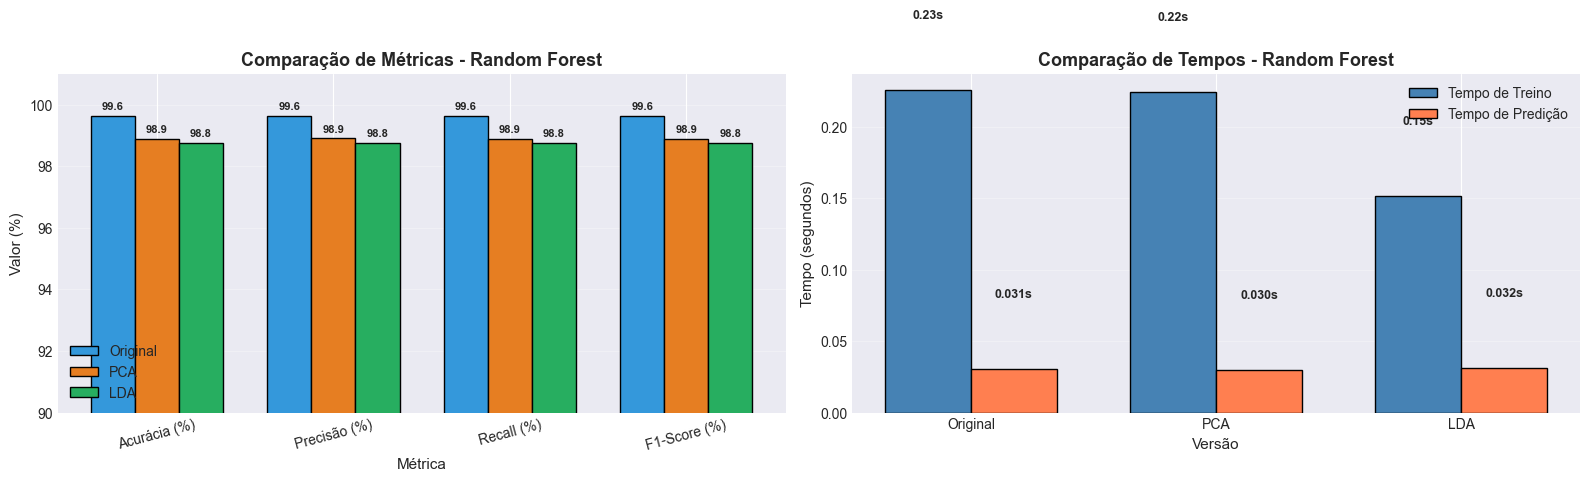

In [7]:
# visualização comparativa em gráfico de barras
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# gráfico das métricas de classificação
metricas = ['Acurácia (%)', 'Precisão (%)', 'Recall (%)', 'F1-Score (%)']
versoes = ['Original', 'PCA', 'LDA']
cores = ['#3498db', '#e67e22', '#27ae60']

x_pos = np.arange(len(metricas))
largura = 0.25

for i, versao in enumerate(versoes):
    valores = [df_comparacao.loc[df_comparacao['Versão'] == versao, m].values[0] for m in metricas]
    axes[0].bar(x_pos + i*largura, valores, largura, label=versao, color=cores[i], edgecolor='black')

axes[0].set_xlabel('Métrica', fontsize=11)
axes[0].set_ylabel('Valor (%)', fontsize=11)
axes[0].set_title('Comparação de Métricas - Random Forest', fontsize=13, fontweight='bold')
axes[0].set_xticks(x_pos + largura)
axes[0].set_xticklabels(metricas, rotation=15)
axes[0].legend(fontsize=10)
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim([min(df_comparacao[metricas].values.min() - 2, 90), 101])

# adicionando valores nas barras
for i, versao in enumerate(versoes):
    valores = [df_comparacao.loc[df_comparacao['Versão'] == versao, m].values[0] for m in metricas]
    for j, v in enumerate(valores):
        axes[0].text(x_pos[j] + i*largura, v + 0.2, f'{v:.1f}', 
                     ha='center', fontsize=8, fontweight='bold')

# gráfico dos tempos de execução
tempos_treino = df_comparacao['Tempo Treino (s)'].values
tempos_pred = df_comparacao['Tempo Pred. (s)'].values

x_pos2 = np.arange(len(versoes))
largura2 = 0.35

axes[1].bar(x_pos2 - largura2/2, tempos_treino, largura2, 
            label='Tempo de Treino', color='steelblue', edgecolor='black')
axes[1].bar(x_pos2 + largura2/2, tempos_pred, largura2, 
            label='Tempo de Predição', color='coral', edgecolor='black')

axes[1].set_xlabel('Versão', fontsize=11)
axes[1].set_ylabel('Tempo (segundos)', fontsize=11)
axes[1].set_title('Comparação de Tempos - Random Forest', fontsize=13, fontweight='bold')
axes[1].set_xticks(x_pos2)
axes[1].set_xticklabels(versoes)
axes[1].legend(fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

# adicionando valores
for i, (t, p) in enumerate(zip(tempos_treino, tempos_pred)):
    axes[1].text(i - largura2/2, t + 0.05, f'{t:.2f}s', ha='center', fontweight='bold', fontsize=9)
    axes[1].text(i + largura2/2, p + 0.05, f'{p:.3f}s', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()


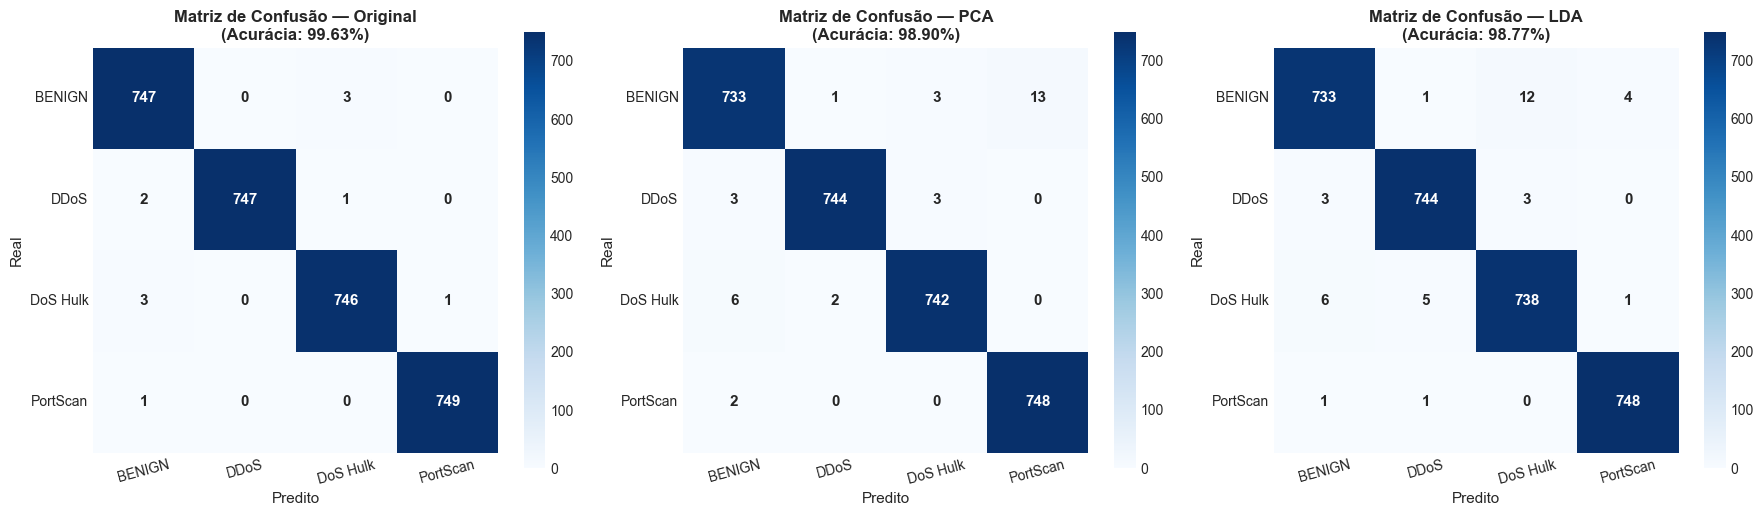

  Diagonal principal = acertos
  Fora da diagonal   = erros
  Linha = classe real | Coluna = classe de previsão


In [8]:
# mostrando as 3 matrizes de confusão lado a lado
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

nomes_classes = list(codificador.classes_)

for idx, (versao, dados) in enumerate(resultados.items()):
    cm = confusion_matrix(y_test, dados['y_pred'])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=nomes_classes, yticklabels=nomes_classes,
                ax=axes[idx], cbar=True, square=True,
                annot_kws={'fontsize': 11, 'fontweight': 'bold'})
    
    axes[idx].set_xlabel('Predito', fontsize=11)
    axes[idx].set_ylabel('Real', fontsize=11)
    axes[idx].set_title(f'Matriz de Confusão — {versao}\n(Acurácia: {dados["acuracia"]*100:.2f}%)',
                        fontsize=12, fontweight='bold')
    axes[idx].tick_params(axis='x', rotation=15)
    axes[idx].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()


print("  Diagonal principal = acertos")
print("  Fora da diagonal   = erros")
print("  Linha = classe real | Coluna = classe de previsão")


In [9]:
# mostrando o relatório de classificação completo para cada versão
nomes_classes = list(codificador.classes_)

for versao, dados in resultados.items():
    print(f"\n{'='*65}")
    print(f"Relatório de classificação — Random Forest ({versao})")
    print(f"{'='*65}")
    print(classification_report(
        y_test, dados['y_pred'],
        target_names=nomes_classes,
        digits=4
    ))



Relatório de classificação — Random Forest (Original)
              precision    recall  f1-score   support

      BENIGN     0.9920    0.9960    0.9940       750
        DDoS     1.0000    0.9960    0.9980       750
    DoS Hulk     0.9947    0.9947    0.9947       750
    PortScan     0.9987    0.9987    0.9987       750

    accuracy                         0.9963      3000
   macro avg     0.9963    0.9963    0.9963      3000
weighted avg     0.9963    0.9963    0.9963      3000


Relatório de classificação — Random Forest (PCA)
              precision    recall  f1-score   support

      BENIGN     0.9852    0.9773    0.9813       750
        DDoS     0.9960    0.9920    0.9940       750
    DoS Hulk     0.9920    0.9893    0.9907       750
    PortScan     0.9829    0.9973    0.9901       750

    accuracy                         0.9890      3000
   macro avg     0.9890    0.9890    0.9890      3000
weighted avg     0.9890    0.9890    0.9890      3000


Relatório de classificaç

Top 15 features (atributos) Mais Importantes da versão original



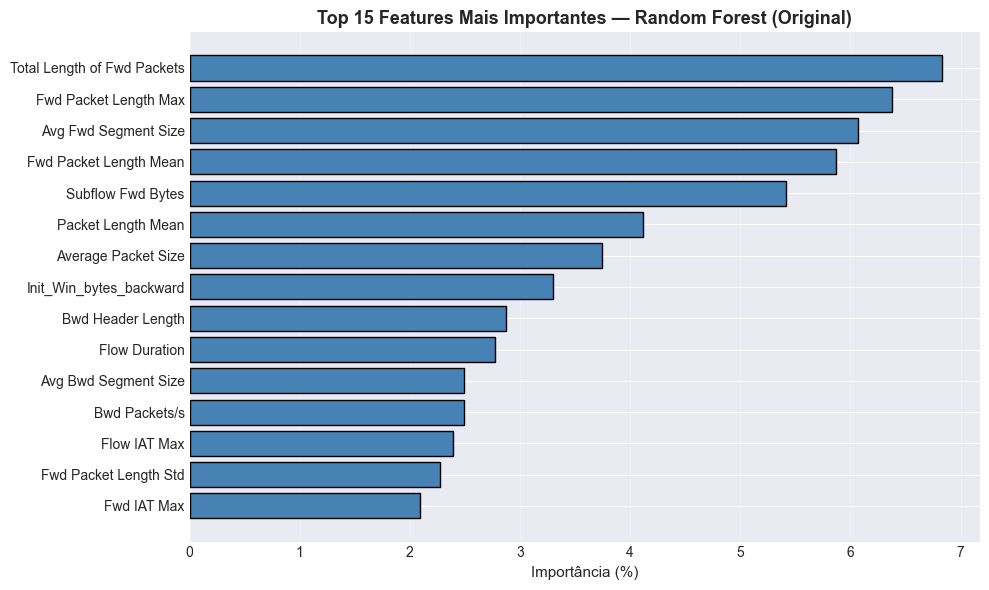

                    Feature  Importância
Total Length of Fwd Packets     0.068344
      Fwd Packet Length Max     0.063779
       Avg Fwd Segment Size     0.060676
     Fwd Packet Length Mean     0.058660
          Subflow Fwd Bytes     0.054120
         Packet Length Mean     0.041179
        Average Packet Size     0.037474
    Init_Win_bytes_backward     0.032999
          Bwd Header Length     0.028746
              Flow Duration     0.027687
       Avg Bwd Segment Size     0.024913
              Bwd Packets/s     0.024906
               Flow IAT Max     0.023925
      Fwd Packet Length Std     0.022721
                Fwd IAT Max     0.020933


In [10]:
# análise de importância das features para a versão Original
# funcionalidade especial que o random forest possibilita

print("Top 15 features (atributos) Mais Importantes da versão original\n")

modelo_original = resultados['Original']['modelo']
importancias = modelo_original.feature_importances_
nomes_features = X_train_orig.columns

# criando dataframe com importâncias
df_importancia = pd.DataFrame({
    'Feature': nomes_features,
    'Importância': importancias
}).sort_values('Importância', ascending=False).head(15)


plt.figure(figsize=(10, 6))
plt.barh(df_importancia['Feature'][::-1], df_importancia['Importância'][::-1] * 100, 
         color='steelblue', edgecolor='black')
plt.xlabel('Importância (%)', fontsize=11)
plt.title('Top 15 Features Mais Importantes — Random Forest (Original)', 
          fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

# tabela
print(df_importancia.to_string(index=False))


In [11]:
# salvando os 3 modelos treinados e as métricas
print("Salvando modelos e métricas\n")

# caminhos para salvar os modelos
caminhos_modelos = {
    'Original': os.path.join(pasta_modelos, 'modelo_rf_original.pkl'),
    'PCA': os.path.join(pasta_modelos, 'modelo_rf_pca.pkl'),
    'LDA': os.path.join(pasta_modelos, 'modelo_rf_lda.pkl')
}

# salvando cada modelo
for versao, caminho in caminhos_modelos.items():
    joblib.dump(resultados[versao]['modelo'], caminho)
    tamanho_mb = os.path.getsize(caminho) / (1024 * 1024)
    print(f"  Modelo random forest {versao}: {caminho} ({tamanho_mb:.2f} MB)")

# salvando métricas num arquivo csv para análise em proximas etapas
pasta_resultados = '../resultados/metricas/'
os.makedirs(pasta_resultados, exist_ok=True)

caminho_metricas = os.path.join(pasta_resultados, 'metricas_random_forest.csv')
df_comparacao.to_csv(caminho_metricas, index=False)
print(f"\n Métricas salvas: {caminho_metricas}")



Salvando modelos e métricas

  Modelo random forest Original: ../modelos/modelo_rf_original.pkl (1.12 MB)
  Modelo random forest PCA: ../modelos/modelo_rf_pca.pkl (2.65 MB)
  Modelo random forest LDA: ../modelos/modelo_rf_lda.pkl (2.01 MB)

 Métricas salvas: ../resultados/metricas/metricas_random_forest.csv


In [12]:
# resumo 
print("\n" + "="*65)
print("RESUMO FINAL — Random Forest")
print("="*65)

print(f"\nModelos treinados: 3 (Original, PCA, LDA)")
print(f"\nRanking por F1-Score:")
ranking = df_comparacao.sort_values('F1-Score (%)', ascending=False)
for i, (_, row) in enumerate(ranking.iterrows(), 1):
    print(f"   {i}º — {row['Versão']:<10} F1: {row['F1-Score (%)']:.2f}%  |  Acc: {row['Acurácia (%)']:.2f}%")

print(f"\nEficiência:")
mais_rapido_treino = df_comparacao.loc[df_comparacao['Tempo Treino (s)'].idxmin(), 'Versão']
mais_rapido_pred = df_comparacao.loc[df_comparacao['Tempo Pred. (s)'].idxmin(), 'Versão']
print(f"  Treinamento mais rápido:  {mais_rapido_treino}")
print(f"  Predição mais rápida:     {mais_rapido_pred}")





RESUMO FINAL — Random Forest

Modelos treinados: 3 (Original, PCA, LDA)

Ranking por F1-Score:
   1º — Original   F1: 99.63%  |  Acc: 99.63%
   2º — PCA        F1: 98.90%  |  Acc: 98.90%
   3º — LDA        F1: 98.77%  |  Acc: 98.77%

Eficiência:
  Treinamento mais rápido:  LDA
  Predição mais rápida:     PCA
